In [1]:
import numpy as np
import matplotlib.pyplot as plt
import simulation_cpu  as sim
from tqdm import tqdm

# import scipy.special as scp
# import analyze_tool as an

besic defentin for all run

In [2]:
# besic stuff
lamda = 8e-7 
time_cycal= lamda/sim.c
time_cut = 100
dt = time_cycal/time_cut
dz = 2*sim.c *dt

# difind matiral as void
eps_r = 1
sigma = 0
close_system = False


# spaece and time defntion
z1 = 10
z2 = 11 
lenz= z2 + 10
save_loc = [4, z1 ,z2, z2+1]
save_time= []



run singel simulation, chack ms size stay conset and extend the ms chang
find arrya to work around

In [6]:
# ms proprty
ms0 = 3e5*np.array([1, 0, 0])
alpha =2*0.025

# pulse porpry
bwhp = 20*time_cycal 
max_E = 5e8
fea = -np.pi/2
peak_enter_time = 2* (np.log(2)**-0.5) * bwhp
run_steps = int(4*peak_enter_time//dt+100)


In [7]:

time_res, spece_res = sim.simulation(z1, z2, eps_r , sigma, alpha, ms0,
        max_E, fea , bwhp,
        save_loc, save_time, False,
        dt, run_steps, lamda )

E_real= sim.heta*spece_res[1]
H = spece_res[0]
S = np.cross(np.real(E_real),np.real(H))
msi = spece_res[2]
msi_size = ( msi[:,0,0]**2 +msi[:,0,1]**2 + msi[:,0,2]**2)**0.5
valid_chak = 100 * (max(abs(msi_size-max(ms0)))/max(ms0))
print(f"ms max chang in {valid_chak: 3e} % of original size")



ms max chang in  8.149073e-13 % of original size


Text(0.5, 0, 'step in time')

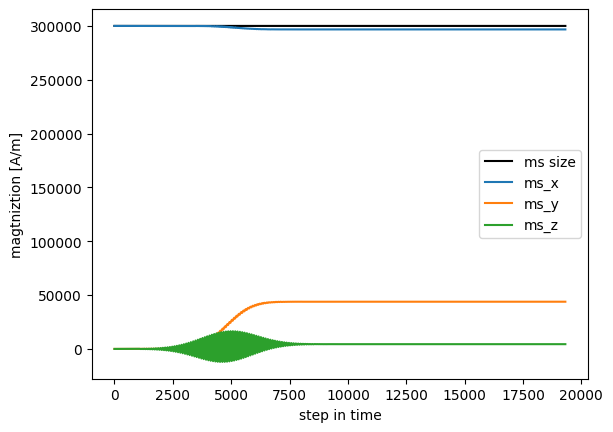

In [8]:
t = np.arange(0, run_steps)


plt.plot(t, msi_size,"k")
plt.plot(t, msi[:,0,0])
plt.plot(t, msi[:,0,1])
plt.plot(t, msi[:,0,2])


plt.legend(["ms size" , "ms_x", "ms_y", "ms_z"])
plt.ylabel("magtniztion [A/m]")
plt.xlabel("step in time")


מציעת התדר הטבעי של מערכת ללא דאיכת גילברט 
אנו מצפים להגיע לתוצאה של:
w0 = gma* H_ext

m0 = np.

us 3.929625187584029e-12 sec det : 100%|██████████| 26/26 [00:00<00:00, 1661.29it/s]


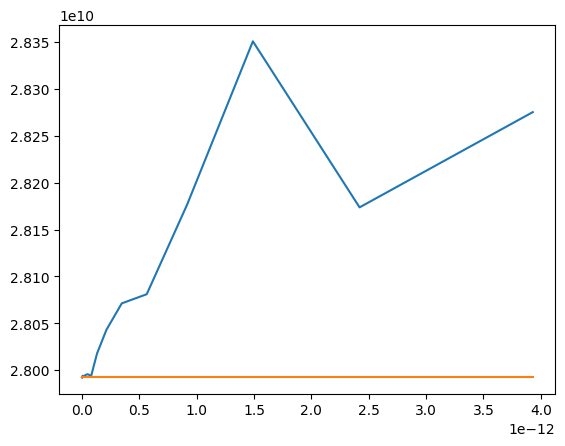

In [7]:

T = 795774.7 # [T] to A/m
H_ext = T* np.array([0,0, 1]).reshape((1,3))
gma_vik = 1.76085e11 #rad/sec*T
dt_vec = np.linspace(0.001,0.1, 20)


f_expte = sim.gma * 1/(2*np.pi)
time_cycle = 1/f_expte

dt_vec  = 1.1*time_cycle*np.logspace(-5, -1, 20)
messer_freq = np.zeros(len(dt_vec))
for i, dt in enumerate(dt_vec):


# step_to_run = int(10000*time_cycel/dt)
    step_to_run = int(3*time_cycle/dt)
    ms = np.zeros((step_to_run,1, 3))
    # t = np.arange(0, step_to_run)*dt
    ms[0,:,:] = np.array([0.3, 0.4, 0.5]).reshape((1,1,3))


    for n in tqdm(range(1, step_to_run), desc= f"us {dt} sec det : "):
        ms[n,:,:] = sim.LLG_step(ms[n-1,:,:],H_ext, dt, 0)


    x = np.squeeze(ms[:,:,0])
    y = np.squeeze(ms[:,:,1])
# z = ms[:,:,2]
# plt.plot(t,ms[:,:,0])
# plt.plot(t, ms[:,:,1])
# plt.plot(t, ms[:,:,2])
# plt.legend(["m_x", "m_y", "m_z"])
# plt.show()
# plt.close()
    freq = np.fft.rfftfreq(step_to_run,d = dt)
    ms_x_fft = np.fft.rfft(x)
# plt.plot(freq, abs(ms_x_fft))
# plt.show()
    ind = list(abs(ms_x_fft)).index(max(abs(ms_x_fft)))
    messer_freq[i] = freq[ind]

plt.plot(dt_vec, messer_freq)
plt.plot(dt_vec, f_expte*np.ones(len(dt_vec)))

d = {"dt_vec" : dt_vec ,"messer_f" : messer_freq, "f_expte" : f_expte}
path = "C:\maxwell-LLG\ws\simulation_result\\"
np.save(path+ "LLG_vervication.npy", d)